# Oslo Bysykkel — Feature Engineering & Model Training

Loads the merged hourly dataset, engineers all features, then trains and evaluates two XGBoost regressors: one for weekdays (Mon–Fri) and one for weekends (Sat–Sun).

**Input:** `output/merged_hourly.csv`  
**Output:** `output/model_weekday.joblib`, `output/model_weekend.joblib`

## 0 · Configuration

In [1]:
from pathlib import Path

INPUT_PATH    = Path("output/merged_hourly.csv")
HOLIDAYS_PATH = Path("input/oslo_holidays_2020_2027.csv")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

## 1 · Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

## 2 · Load merged hourly data

In [3]:
df = pd.read_csv(INPUT_PATH, parse_dates=["hour"])
df = df.sort_values("hour").reset_index(drop=True)

print(f"Loaded {len(df):,} rows  ({df['hour'].min()} → {df['hour'].max()})")
print(f"Columns: {df.columns.tolist()}")

Loaded 43,332 rows  (2020-03-18 00:00:00 → 2026-03-03 19:00:00)
Columns: ['hour', 'trip_count', 'avg_duration_min', 'median_duration_min', 'temp_c', 'precip_mm', 'wind_speed_ms', 'cloud_area_fraction', 'date', 'hour_of_day', 'day_of_week', 'is_weekend', 'month']


## 3 · Cyclical encoding

Hour-of-day, month, and day-of-year are all circular: hour 23 is one step from hour 0, not 23 steps away. Encoding them as sin/cos pairs preserves that continuity for the model, unlike raw integer values.

In [4]:
def cyclical(series: pd.Series, period: int):
    """Return sin and cos encodings for a circular feature."""
    radians = 2 * np.pi * series / period
    return np.sin(radians), np.cos(radians)

# Hour of day (period 24)
df["hour_sin"], df["hour_cos"] = cyclical(df["hour_of_day"], 24)

# Month (period 12)
df["month_sin"], df["month_cos"] = cyclical(df["month"], 12)

# Day of year (period 365) — finer seasonal resolution than month
df["day_of_year"] = df["hour"].dt.dayofyear
df["doy_sin"], df["doy_cos"] = cyclical(df["day_of_year"], 365)

print("Cyclical features added:")
cyc_cols = ["hour_sin", "hour_cos", "month_sin", "month_cos", "doy_sin", "doy_cos"]
print(df[cyc_cols].describe().round(3))

Cyclical features added:
        hour_sin   hour_cos  month_sin  month_cos    doy_sin    doy_cos
count  43332.000  43332.000  43332.000  43332.000  43332.000  43332.000
mean      -0.119     -0.154     -0.014     -0.004     -0.008     -0.004
std        0.712      0.675      0.704      0.710      0.706      0.709
min       -1.000     -1.000     -1.000     -1.000     -1.000     -1.000
25%       -0.866     -0.866     -0.866     -0.866     -0.712     -0.709
50%       -0.259     -0.259     -0.000     -0.000     -0.017     -0.013
75%        0.500      0.259      0.500      0.866      0.693      0.715
max        1.000      1.000      1.000      1.000      1.000      1.000


### 3a · Visualise cyclical encoding

A quick sanity check, plotting the sin/cos pairs should trace smooth circles.

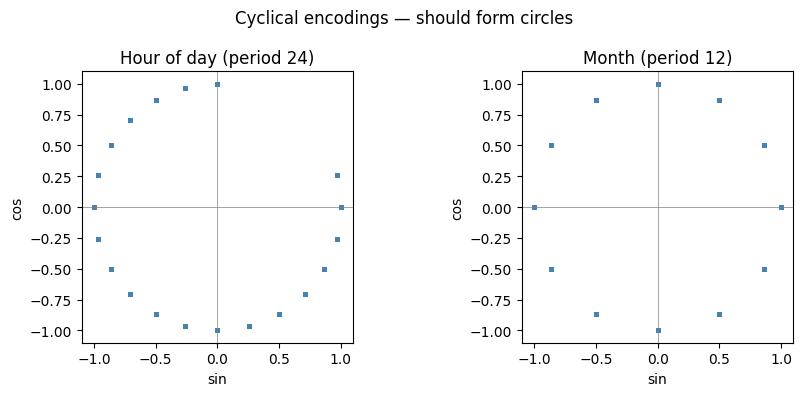

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

pairs = [
    ("hour_sin",  "hour_cos",  "Hour of day (period 24)"),
    ("month_sin", "month_cos", "Month (period 12)"),
]

for ax, (s_col, c_col, title) in zip(axes, pairs):
    ax.scatter(df[s_col], df[c_col], alpha=0.05, s=6, color="steelblue")
    ax.set_xlabel("sin")
    ax.set_ylabel("cos")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.axhline(0, color="grey", lw=0.5)
    ax.axvline(0, color="grey", lw=0.5)

plt.suptitle("Cyclical encodings — should form circles", fontsize=12)
plt.tight_layout()
plt.show()

## 4 · Lag features

A 1-hour lag of `precip_mm` captures recent weather momentum — whether it has been raining in the hour leading up to a given slot. This lag is available at forecast time since it is derived from the weather forecast itself.

`trip_count` short-range lags are **not** included: they would not be available when forecasting days ahead.

In [6]:
df["precip_mm_lag1h"] = df["precip_mm"].shift(1)
print(f"Added precip_mm_lag1h  ({df['precip_mm_lag1h'].isna().sum()} NaN rows to drop)")

Added precip_mm_lag1h  (142 NaN rows to drop)


### 4a · Check lag feature distribution

In [7]:
df[["precip_mm", "precip_mm_lag1h"]].describe().round(2)

,precip_mm,precip_mm_lag1h
count,43191.00,43190.00
mean,0.10,0.10
std,0.54,0.54
min,0.00,0.00
25%,0.00,0.00
50%,0.00,0.00
75%,0.00,0.00
max,32.50,32.50


### 4b · Drop rows with NaN lag values

The first row will be missing the 1h lag — drop it so the training set is fully populated.

In [8]:
before = len(df)
df = df.dropna(subset=["precip_mm_lag1h"]).reset_index(drop=True)
print(f"Dropped {before - len(df):,} rows with NaN lag values  ({len(df):,} remaining)")

Dropped 142 rows with NaN lag values  (43,190 remaining)


In [9]:
# Oslo school holidays & national holidays
holidays_csv = pd.read_csv(HOLIDAYS_PATH)
holidays_csv["date"] = pd.to_datetime(holidays_csv["date"], format="%d-%m-%Y").dt.date
_school_holiday_dates   = set(holidays_csv.loc[holidays_csv["oslo_school_holiday"],   "date"])
_national_holiday_dates = set(holidays_csv.loc[holidays_csv["national_holiday"],      "date"])

df["is_school_holiday"]   = df["hour"].dt.date.map(lambda d: int(d in _school_holiday_dates))
df["is_national_holiday"] = df["hour"].dt.date.map(lambda d: int(d in _national_holiday_dates))

flag_cols = ["is_school_holiday", "is_national_holiday"]

print("Holiday flag value counts:")
print(df[flag_cols].sum().rename("n_true").to_frame().assign(
    pct=lambda x: (100 * x["n_true"] / len(df)).round(1)
))

Holiday flag value counts:
                     n_true   pct
is_school_holiday     10681  24.7
is_national_holiday    1361   3.2


In [10]:
# Consecutive dry days: number of preceding days (including today) with daily
# precip < 1 mm. Resets to 0 on any wet day.
daily_precip = (
    df.groupby(df["hour"].dt.date)["precip_mm"]
    .sum()
    .reset_index()
    .rename(columns={"hour": "date", "precip_mm": "daily_precip_mm"})
)

consecutive = []
count = 0
for is_dry in (daily_precip["daily_precip_mm"] < 1.0):
    count = count + 1 if is_dry else 0
    consecutive.append(count)
daily_precip["consecutive_dry_days"] = consecutive

date_to_cdd = daily_precip.set_index("date")["consecutive_dry_days"].to_dict()
df["consecutive_dry_days"] = df["hour"].dt.date.map(date_to_cdd)

print("consecutive_dry_days distribution:")
print(df["consecutive_dry_days"].describe().round(1))
print(f"\nDays with streak >= 5: {(daily_precip['consecutive_dry_days'] >= 5).sum()}")

consecutive_dry_days distribution:
count    43190.0
mean         4.2
std          5.4
min          0.0
25%          0.0
50%          2.0
75%          6.0
max         34.0
Name: consecutive_dry_days, dtype: float64

Days with streak >= 5: 708


## 5a · Remove service closure hours

Bysykkel is closed every day from 01:00 to 04:59 Oslo local time, i.e. no trips can be started between those hours. These rows are excluded from training so the model never learns on near-zero targets caused by a hard operational constraint rather than any weather or calendar signal. At forecast time the same hours are set to zero directly (without running the model).

In [11]:
CLOSED_HOURS = [1, 2, 3, 4]   # 01:00–04:59 Oslo time

before = len(df)
df = df[~df["hour_of_day"].isin(CLOSED_HOURS)].reset_index(drop=True)
print(f"Removed {before - len(df):,} service-closure rows  ({len(df):,} remaining)")

Removed 0 service-closure rows  (43,190 remaining)


In [12]:
# Total trips in the previous calendar year
# This is the only trip-count-derived feature used: it captures the
# year-on-year growth trend and is always fully available at forecast time.
annual = (
    df.groupby(df["hour"].dt.year)["trip_count"]
    .sum()
    .reset_index()
    .rename(columns={"hour": "year", "trip_count": "prev_year_trips"})
)
annual["year"] += 1   # shift: 2022 total becomes the feature for 2023
df["year"] = df["hour"].dt.year
df = df.merge(annual, on="year", how="left").drop(columns="year")

# Drop the first calendar year (no previous year available)
before = len(df)
df = df.dropna(subset=["prev_year_trips"]).reset_index(drop=True)
print(f"Dropped {before - len(df):,} rows missing prev_year_trips  ({len(df):,} remaining)")
print(f"\nprev_year_trips value counts by year:")
print(df.groupby(df["hour"].dt.year)["prev_year_trips"].first())

Dropped 5,771 rows missing prev_year_trips  (37,419 remaining)

prev_year_trips value counts by year:
hour
2021    1694414.0
2022    1417955.0
2023    1284915.0
2024    1080933.0
2025    1142197.0
2026    1112055.0
Name: prev_year_trips, dtype: float64


## 6 · Final feature set overview

In [13]:
feature_cols = (
    # Raw weather
    ["temp_c", "precip_mm", "wind_speed_ms", "cloud_area_fraction"]
    # Calendar
    + ["hour_of_day", "day_of_week"]
    # Cyclical encodings
    + ["hour_sin", "hour_cos", "month_sin", "month_cos", "doy_sin", "doy_cos"]
    # 1-hour precipitation lag
    + ["precip_mm_lag1h"]
    # Previous year total trips (growth trend — always available)
    + ["prev_year_trips"]
    # Holiday flags
    + flag_cols
    # Dry spell
    + ["consecutive_dry_days"]
)

# Keep only columns that actually exist
feature_cols = [c for c in feature_cols if c in df.columns]

print(f"Target   : trip_count")
print(f"Features : {len(feature_cols)}")
print()
for col in feature_cols:
    null_pct = 100 * df[col].isna().mean()
    print(f"  {col:<35} dtype={str(df[col].dtype):<12} nulls={null_pct:.1f}%")

Target   : trip_count
Features : 17

  temp_c                              dtype=float64      nulls=0.0%
  precip_mm                           dtype=float64      nulls=0.0%
  wind_speed_ms                       dtype=float64      nulls=0.0%
  cloud_area_fraction                 dtype=float64      nulls=0.0%
  hour_of_day                         dtype=int64        nulls=0.0%
  day_of_week                         dtype=int64        nulls=0.0%
  hour_sin                            dtype=float64      nulls=0.0%
  hour_cos                            dtype=float64      nulls=0.0%
  month_sin                           dtype=float64      nulls=0.0%
  month_cos                           dtype=float64      nulls=0.0%
  doy_sin                             dtype=float64      nulls=0.0%
  doy_cos                             dtype=float64      nulls=0.0%
  precip_mm_lag1h                     dtype=float64      nulls=0.0%
  prev_year_trips                     dtype=float64      nulls=0.0%
  is_school

### 6a · Correlation of engineered features with trip_count

In [14]:
from scipy import stats

print(f"{'Feature':<30} {'Pearson r':>10}  {'p-value':>10}  sig")
print("─" * 58)
for col in feature_cols:
    sub = df[["trip_count", col]].dropna()
    r, p = stats.pearsonr(sub[col], sub["trip_count"])
    stars = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"{col:<30} {r:>+10.3f}  {p:>10.4f}  {stars}")

Feature                         Pearson r     p-value  sig
──────────────────────────────────────────────────────────
temp_c                             +0.633      0.0000  ***
precip_mm                          -0.072      0.0000  ***
wind_speed_ms                      +0.107      0.0000  ***
cloud_area_fraction                -0.117      0.0000  ***
hour_of_day                        +0.126      0.0000  ***
day_of_week                        -0.128      0.0000  ***
hour_sin                           -0.204      0.0000  ***
hour_cos                           -0.225      0.0000  ***
month_sin                          -0.346      0.0000  ***
month_cos                          -0.476      0.0000  ***
doy_sin                            -0.214      0.0000  ***
doy_cos                            -0.552      0.0000  ***
precip_mm_lag1h                    -0.054      0.0000  ***
prev_year_trips                    +0.112      0.0000  ***
is_school_holiday                  +0.112      0.0000  *

## 7 · Save

In [15]:
out_cols  = ["hour", "trip_count"] + feature_cols
out_path  = OUTPUT_DIR / "features_hourly.csv"
df[out_cols].to_csv(out_path, index=False)

print(f"Saved → {out_path.resolve()}")
print(f"Shape  : {df.shape[0]:,} rows × {len(out_cols)} columns")

Saved → /Users/dylan/Projects/BysykkelForecast/output/features_hourly.csv
Shape  : 37,419 rows × 19 columns


---

## Part 2 · Model Training

The feature dataset produced above feeds directly into two XGBoost regressors trained with time-series cross-validation. A weekday model (Mon–Fri) and a weekend model (Sat–Sun) are trained separately, then tuned with `RandomizedSearchCV` and evaluated on a held-out final test set.

In [16]:
import warnings
warnings.filterwarnings("ignore")
import joblib
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats             import randint, uniform
from xgboost                 import XGBRegressor

N_SPLITS  = 5          # number of rolling CV folds
TEST_SIZE = 24 * 30    # ~1 month of hours per fold

## 3 · Define features and target

`hour` is the index, `trip_count` is the target. All remaining engineered columns are used as features.

In [17]:
TARGET = "trip_count"
FEATURE_COLS = feature_cols   # defined in Part 1

X = df[FEATURE_COLS].values
y = df[TARGET].values

print(f"Features : {len(FEATURE_COLS)}")
print(f"Samples  : {len(y):,}")
print(f"Target   : min={y.min():.0f}  max={y.max():.0f}  mean={y.mean():.1f}")
print(f"\nFeature list:")
for c in FEATURE_COLS:
    print(f"  {c}")

Features : 17
Samples  : 37,419
Target   : min=1  max=1029  mean=161.9

Feature list:
  temp_c
  precip_mm
  wind_speed_ms
  cloud_area_fraction
  hour_of_day
  day_of_week
  hour_sin
  hour_cos
  month_sin
  month_cos
  doy_sin
  doy_cos
  precip_mm_lag1h
  prev_year_trips
  is_school_holiday
  is_national_holiday
  consecutive_dry_days


## 4 · Cross-validation setup

We use `TimeSeriesSplit` with a fixed `test_size` so every fold evaluates on the same number of hours (~1 month). Each fold trains on all data before the test window, no shuffling, no leakage.

In [18]:
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE)

# Preview fold sizes
print(f"{'Fold':<6} {'Train hours':>12}  {'Test hours':>12}")
print("─" * 34)
for fold, (tr, te) in enumerate(tscv.split(X), 1):
    print(f"{fold:<6} {len(tr):>12,}  {len(te):>12,}")

Fold    Train hours    Test hours
──────────────────────────────────
1            33,819           720
2            34,539           720
3            35,259           720
4            35,979           720
5            36,699           720


In [19]:
def mape(y_true, y_pred, eps=1e-6):
    """Mean Absolute Percentage Error, guarded against zero actuals."""
    mask = np.abs(y_true) > eps
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def evaluate(y_true, y_pred) -> dict:
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
    }

## 5 · Define models

Two XGBoost regressors with identical starting hyperparameters are prepared. One trained exclusively on weekday hours (Mon–Fri) and one on weekend hours (Sat–Sun). Day-type-specific patterns (commute peaks vs. leisure rides) are better captured by separate models than by a single model with `is_weekend` as a feature.

In [20]:
# Day-type masks (numpy bool arrays for clean indexing)
mask_weekday = df["day_of_week"].isin([0, 1, 2, 3, 4]).values
mask_weekend = ~mask_weekday

X_weekday, y_weekday = X[mask_weekday], y[mask_weekday]
X_weekend, y_weekend = X[mask_weekend], y[mask_weekend]

print(f"Weekday samples : {mask_weekday.sum():,}")
print(f"Weekend samples : {mask_weekend.sum():,}")

XGB_PARAMS = dict(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
)

MODELS = {
    "Weekday": XGBRegressor(**XGB_PARAMS),
    "Weekend": XGBRegressor(**XGB_PARAMS),
}
SPLITS = {
    "Weekday": (X_weekday, y_weekday),
    "Weekend": (X_weekend, y_weekend),
}

Weekday samples : 26,756
Weekend samples : 10,663


## 6 · Train and evaluate

Each model is evaluated across all CV folds on its respective day-type subset.

In [21]:
all_results = {}

for name, (Xi, yi) in SPLITS.items():
    print(f"  Training {name} XGBoost...", end=" ", flush=True)
    fold_metrics = []
    model = MODELS[name]
    for fold, (tr_idx, te_idx) in enumerate(tscv.split(Xi), 1):
        model.fit(Xi[tr_idx], yi[tr_idx])
        preds = np.clip(model.predict(Xi[te_idx]), 0, None)
        fold_metrics.append(evaluate(yi[te_idx], preds))
    all_results[name] = fold_metrics
    mean_mae = np.mean([m["MAE"] for m in fold_metrics])
    print(f"done  (mean MAE: {mean_mae:.1f} trips/hr)")

  Training Weekday XGBoost... done  (mean MAE: 25.9 trips/hr)
  Training Weekend XGBoost... done  (mean MAE: 21.3 trips/hr)


## 7 · Results summary

In [22]:
rows = []
for name, folds in all_results.items():
    for metric in ("MAE", "RMSE", "R2", "MAPE"):
        vals = [f[metric] for f in folds]
        rows.append({
            "Model":  name,
            "Metric": metric,
            "Mean":   np.mean(vals),
            "Std":    np.std(vals),
        })

results_df = pd.DataFrame(rows)

for metric in ("MAE", "RMSE", "R2", "MAPE"):
    print(f"── {metric} {'(higher is better)' if metric == 'R2' else '(lower is better)'}")
    sub = results_df[results_df["Metric"] == metric][["Model", "Mean", "Std"]].copy()
    sub["Mean ± Std"] = sub.apply(lambda r: f"{r['Mean']:.3f} ± {r['Std']:.3f}", axis=1)
    print(sub[["Model", "Mean ± Std"]].to_string(index=False))
    print()

── MAE (lower is better)
  Model     Mean ± Std
Weekday 25.884 ± 9.910
Weekend 21.341 ± 7.761

── RMSE (lower is better)
  Model      Mean ± Std
Weekday 36.697 ± 12.728
Weekend 30.877 ± 10.463

── R2 (higher is better)
  Model    Mean ± Std
Weekday 0.564 ± 0.641
Weekend 0.867 ± 0.023

── MAPE (lower is better)
  Model      Mean ± Std
Weekday 42.043 ± 26.688
Weekend 58.120 ± 33.243



## 8 · Visualise CV results

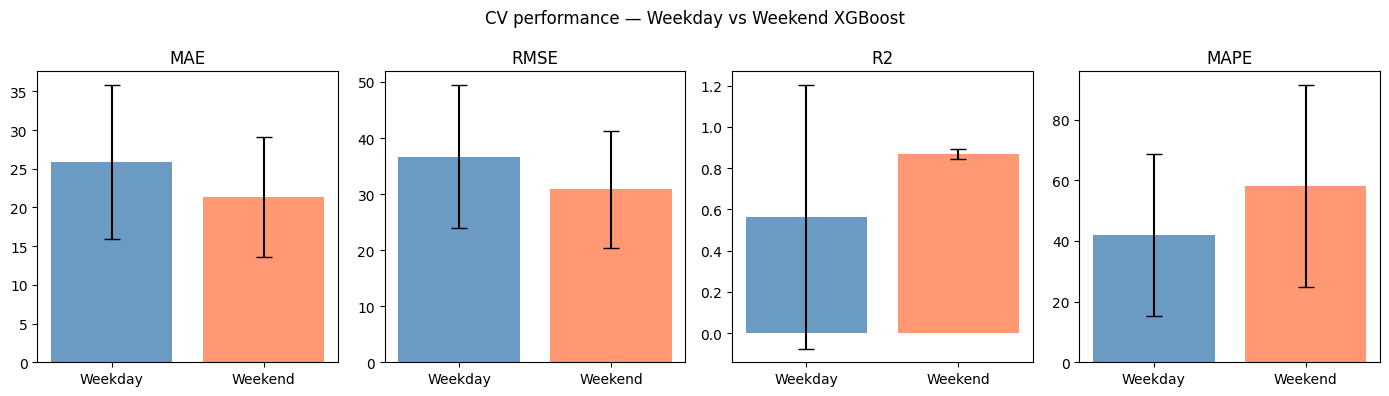

In [23]:
metrics   = ["MAE", "RMSE", "R2", "MAPE"]
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, metric in zip(axes, metrics):
    means = [np.mean([f[metric] for f in all_results[n]]) for n in MODELS]
    stds  = [np.std( [f[metric] for f in all_results[n]]) for n in MODELS]
    ax.bar(MODELS.keys(), means, yerr=stds, capsize=6,
           color=["steelblue", "coral"], alpha=0.8)
    ax.set_title(metric)
    if metric != "R2":
        ax.set_ylim(bottom=0)

plt.suptitle("CV performance — Weekday vs Weekend XGBoost", fontsize=12)
plt.tight_layout()
plt.show()

## 9 · Actual vs. predicted — last fold

Plots the final CV fold (most recent month) for each model so we can inspect where predictions go wrong (e.g. weekends, rush hours, unusual weather...). 

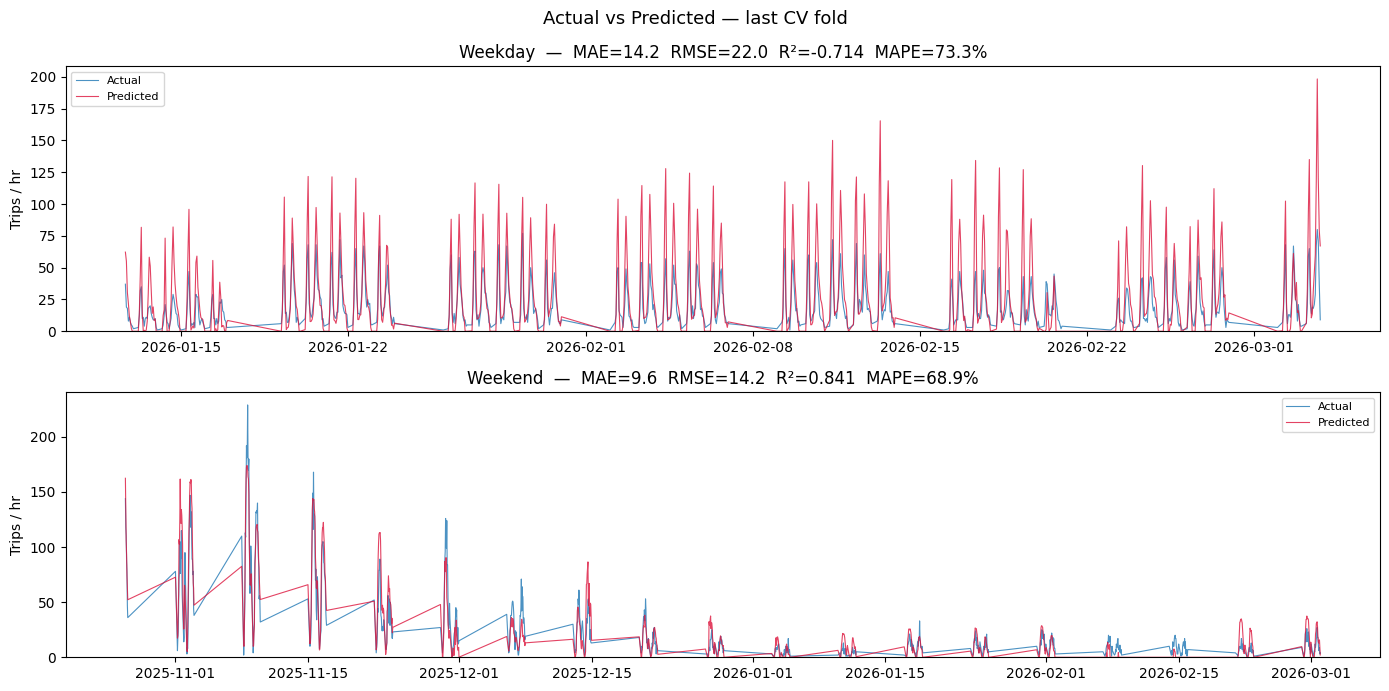

In [24]:
hours_per_split = {
    "Weekday": df["hour"].values[mask_weekday],
    "Weekend": df["hour"].values[mask_weekend],
}

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

for ax, (name, (Xi, yi)) in zip(axes, SPLITS.items()):
    last_tr, last_te = list(tscv.split(Xi))[-1]
    MODELS[name].fit(Xi[last_tr], yi[last_tr])
    preds = np.clip(MODELS[name].predict(Xi[last_te]), 0, None)
    m = evaluate(yi[last_te], preds)
    hours_te = hours_per_split[name][last_te]

    ax.plot(hours_te, yi[last_te], lw=0.8, alpha=0.8, label="Actual")
    ax.plot(hours_te, preds, lw=0.8, alpha=0.8, label="Predicted", color="crimson")
    ax.set_ylabel("Trips / hr")
    ax.set_ylim(bottom=0)
    ax.set_title(f"{name}  —  MAE={m['MAE']:.1f}  RMSE={m['RMSE']:.1f}  R²={m['R2']:.3f}  MAPE={m['MAPE']:.1f}%")
    ax.legend(fontsize=8)

plt.suptitle("Actual vs Predicted — last CV fold", fontsize=13)
plt.tight_layout()
plt.show()

## 10 · Feature importance

Feature importances for each XGBoost model, trained on all data of its respective day type.

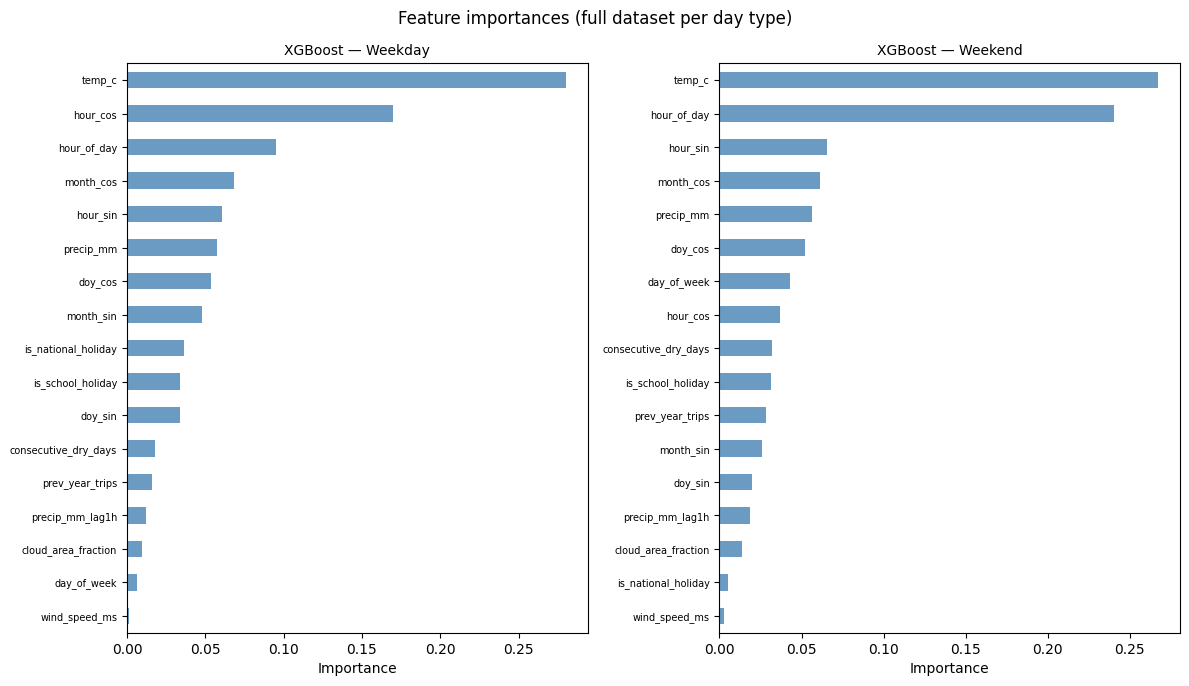

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 0.35 * len(FEATURE_COLS) + 1))

for ax, (name, (Xi, yi)) in zip(axes, SPLITS.items()):
    MODELS[name].fit(Xi, yi)
    imp = pd.Series(MODELS[name].feature_importances_, index=FEATURE_COLS).sort_values()
    imp.plot.barh(ax=ax, color="steelblue", alpha=0.8)
    ax.set_title(f"XGBoost — {name}", fontsize=10)
    ax.set_xlabel("Importance")
    ax.tick_params(axis="y", labelsize=7)

plt.suptitle("Feature importances (full dataset per day type)", fontsize=12)
plt.tight_layout()
plt.show()

## 11 · Hyperparameter tuning

Both models are tuned independently using `RandomizedSearchCV` with the same `TimeSeriesSplit`. A held-out final test set is set aside **before** tuning to give an unbiased estimate of real-world performance. 

In [31]:
HOLDOUT_HOURS = 24 * 90
n = len(df)

dev_idx  = np.arange(n) < (n - HOLDOUT_HOURS)
test_idx = ~dev_idx

X_dev_weekday,  y_dev_weekday  = X[dev_idx  & mask_weekday], y[dev_idx  & mask_weekday]
X_dev_weekend,  y_dev_weekend  = X[dev_idx  & mask_weekend],  y[dev_idx  & mask_weekend]
X_test_weekday, y_test_weekday = X[test_idx & mask_weekday], y[test_idx & mask_weekday]
X_test_weekend, y_test_weekend = X[test_idx & mask_weekend],  y[test_idx & mask_weekend]

hours_test_weekday = df["hour"].values[test_idx & mask_weekday]
hours_test_weekend = df["hour"].values[test_idx & mask_weekend]

print(f"Dev   weekday : {len(y_dev_weekday):,}  |  test weekday : {len(y_test_weekday):,}")
print(f"Dev   weekend : {len(y_dev_weekend):,}  |  test weekend : {len(y_test_weekend):,}")
print(f"Final test window: {df['hour'].iloc[-HOLDOUT_HOURS].date()} → {df['hour'].iloc[-1].date()}")

Dev   weekday : 25,229  |  test weekday : 1,527
Dev   weekend : 10,030  |  test weekend : 633
Final test window: 2025-11-15 → 2026-03-03


In [27]:
tscv_tune = TimeSeriesSplit(n_splits=3, test_size=TEST_SIZE)

PARAM_DIST = {
    "n_estimators":     randint(100, 600),
    "learning_rate":    uniform(0.01, 0.2),
    "max_depth":        randint(3, 8),
    "min_child_weight": randint(2, 20),
    "subsample":        uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.5, 0.5),
}

DEV_SPLITS = {
    "Weekday": (X_dev_weekday, y_dev_weekday),
    "Weekend": (X_dev_weekend, y_dev_weekend),
}

tuned_models = {}
for name, (Xi_dev, yi_dev) in DEV_SPLITS.items():
    print(f"  Tuning {name} XGBoost...", end=" ", flush=True)
    search = RandomizedSearchCV(
        XGBRegressor(random_state=42, verbosity=0),
        param_distributions=PARAM_DIST,
        n_iter=30,
        cv=tscv_tune,
        scoring="neg_mean_absolute_error",
        random_state=42,
        n_jobs=-1,
        refit=True,
    )
    search.fit(Xi_dev, yi_dev)
    tuned_models[name] = search.best_estimator_
    print(f"done  (best CV MAE: {-search.best_score_:.1f})  params: {search.best_params_}")

  Tuning Weekday XGBoost... done  (best CV MAE: 30.3)  params: {'colsample_bytree': np.float64(0.5917022549267169), 'learning_rate': np.float64(0.07084844859190755), 'max_depth': 7, 'min_child_weight': 13, 'n_estimators': 444, 'subsample': np.float64(0.7164916560792167)}
  Tuning Weekend XGBoost... done  (best CV MAE: 21.3)  params: {'colsample_bytree': np.float64(0.6654490124263246), 'learning_rate': np.float64(0.02271167005720473), 'max_depth': 7, 'min_child_weight': 4, 'n_estimators': 271, 'subsample': np.float64(0.8550229885420852)}


### 11a · Evaluate tuned models on final test set

In [28]:
TEST_DATA = {
    "Weekday": (X_test_weekday, y_test_weekday),
    "Weekend": (X_test_weekend, y_test_weekend),
}

print(f"{'Model':<10} {'MAE':>8}  {'RMSE':>8}  {'R²':>8}  {'MAPE':>8}")
print("─" * 50)
final_metrics = {}
for name, (Xi_test, yi_test) in TEST_DATA.items():
    preds = np.clip(tuned_models[name].predict(Xi_test), 0, None)
    m = evaluate(yi_test, preds)
    final_metrics[name] = m
    print(f"{name:<10} {m['MAE']:>8.1f}  {m['RMSE']:>8.1f}  {m['R2']:>8.3f}  {m['MAPE']:>7.1f}%")

Model           MAE      RMSE        R²      MAPE
──────────────────────────────────────────────────
Weekday        11.4      17.7     0.855     60.1%
Weekend         7.1      10.8     0.797     60.6%


**Note**: the current test set runs from late November to early March, which is not exactly the most popular time of year for cycling. It will be interesting to see how the test performance here compares to forecast performance over the coming months. 

### 11b · Actual vs predicted — final test set

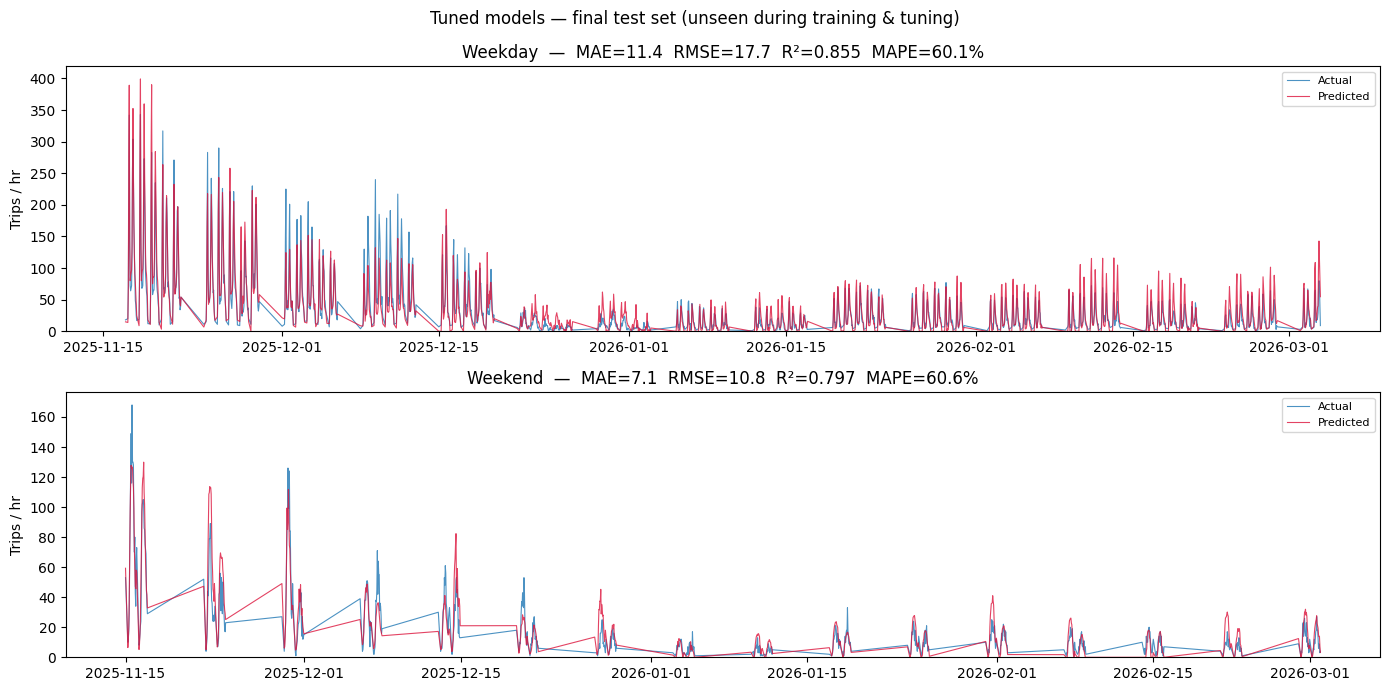

In [29]:
HOURS_TEST = {
    "Weekday": hours_test_weekday,
    "Weekend": hours_test_weekend,
}

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
for ax, name in zip(axes, ["Weekday", "Weekend"]):
    Xi_test, yi_test = TEST_DATA[name]
    preds = np.clip(tuned_models[name].predict(Xi_test), 0, None)
    m = final_metrics[name]
    ax.plot(HOURS_TEST[name], yi_test, lw=0.8, alpha=0.8, label="Actual")
    ax.plot(HOURS_TEST[name], preds,   lw=0.8, alpha=0.8, color="crimson", label="Predicted")
    ax.set_ylabel("Trips / hr")
    ax.set_ylim(bottom=0)
    ax.set_title(f"{name}  —  MAE={m['MAE']:.1f}  RMSE={m['RMSE']:.1f}  R²={m['R2']:.3f}  MAPE={m['MAPE']:.1f}%")
    ax.legend(fontsize=8)

plt.suptitle("Tuned models — final test set (unseen during training & tuning)", fontsize=12)
plt.tight_layout()
plt.show()

## 12 · Save models

Both tuned models are refit on all available data for their respective day type, then saved.

In [30]:
for name, (Xi_all, yi_all) in SPLITS.items():
    model = tuned_models[name]
    model.fit(Xi_all, yi_all)
    path = OUTPUT_DIR / f"model_{name.lower()}.joblib"
    joblib.dump({"model": model, "features": FEATURE_COLS, "name": f"XGBoost {name}"}, path)
    print(f"Saved {name} → {path}  (test MAE: {final_metrics[name]['MAE']:.1f})")

Saved Weekday → output/model_weekday.joblib  (test MAE: 11.4)
Saved Weekend → output/model_weekend.joblib  (test MAE: 7.1)
